# RouteIQ: Urban Delivery Route Optimization

## Section 1: Setup and Data Loading
Importing the necessary libraries to handle data structures, perform analysis, and create visualizations.


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for consistent visualizations
%matplotlib inline
sns.set_theme(style="whitegrid")

# Random seed for reproducibility
np.random.seed(42)


Load the synthetic delivery trips dataset into a Pandas DataFrame and inspect the initial structure.


In [65]:
# Load the dataset
df = pd.read_csv('../data/raw/delivery_trips.csv')

# Inspect the first few rows
display(df.head())

# Check the structure and data types
df.info()

# Summary statistics of numeric columns
display(df.describe())

print(f'\nDataset Shape: {df.shape}')


,trip_id,driver_id,vehicle_type,pickup_area,dropoff_area,distance_km,time_of_day,day_of_week,traffic_index,weather,planned_duration_min,actual_duration_min,delivery_status,driver_experience_days
0,2205,136,scooter,suburb,industrial,10.51,8,Saturday,0.67,rain,26.27,62.11,delayed,105
1,2461,146,bike,central,tech_park,3.48,23,Tuesday,0.19,clear,11.60,26.81,delayed,717
2,1964,107,car,tech_park,central,21.01,21,Sunday,0.57,clear,42.02,64.46,delayed,66
3,1429,115,scooter,tech_park,tech_park,14.70,21,Wednesday,0.50,clear,36.75,56.96,delayed,906
4,1043,108,scooter,central,suburb,16.18,8,Thursday,0.94,clear,40.45,68.56,delayed,709


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   trip_id                 2550 non-null   int64  
 1   driver_id               2550 non-null   int64  
 2   vehicle_type            2550 non-null   object 
 3   pickup_area             2550 non-null   object 
 4   dropoff_area            2550 non-null   object 
 5   distance_km             2509 non-null   float64
 6   time_of_day             2550 non-null   int64  
 7   day_of_week             2550 non-null   object 
 8   traffic_index           2550 non-null   float64
 9   weather                 2520 non-null   object 
 10  planned_duration_min    2550 non-null   float64
 11  actual_duration_min     2518 non-null   float64
 12  delivery_status         2550 non-null   object 
 13  driver_experience_days  2550 non-null   int64  
dtypes: float64(4), int64(4), object(6)
memor

,trip_id,driver_id,distance_km,time_of_day,traffic_index,planned_duration_min,actual_duration_min,driver_experience_days
count,2550.000000,2550.000000,2509.000000,2550.000000,2550.000000,2550.000000,2518.000000,2550.000000
mean,1245.604706,124.753333,12.881255,11.434118,0.483733,34.940337,61.148836,517.392941
std,721.193630,14.532682,6.873726,6.917108,0.193153,19.972274,39.636194,279.138454
min,1.000000,100.000000,1.010000,0.000000,0.100000,2.100000,1.000000,30.000000
25%,620.250000,112.000000,7.040000,5.000000,0.340000,18.435000,30.492500,273.250000
50%,1243.500000,125.000000,12.670000,11.000000,0.450000,33.325000,56.130000,526.000000
75%,1867.750000,137.000000,18.820000,17.000000,0.610000,48.967500,84.857500,751.750000
max,2500.000000,149.000000,25.000000,23.000000,0.970000,83.330000,288.190000,999.000000



Dataset Shape: (2550, 14)


## Section 2: Understanding Data Types & Basic Operations
In this section, we demonstrate working with standard Python data structures (lists, tuples, dictionaries) and perform fundamental operations using NumPy arrays to highlight vectorization and broadcasting.


In [66]:
# Python Lists, Tuples, Dictionaries
sample_distances_list = [5.2, 12.4, 3.1, 8.7, 15.0]
sample_tuple = ('bike', 'car', 'scooter')
sample_dict = {'central': 100, 'suburb': 50, 'old_city': 80}

print("List:", sample_distances_list)
print("Tuple:", sample_tuple)
print("Dictionary:", sample_dict)


List: [5.2, 12.4, 3.1, 8.7, 15.0]
Tuple: ('bike', 'car', 'scooter')
Dictionary: {'central': 100, 'suburb': 50, 'old_city': 80}


In [67]:
# Create a NumPy array from a list of distances
distances_array = np.array(sample_distances_list)

print("Array:", distances_array)
print("Shape:", distances_array.shape)
print("Dimensions:", distances_array.ndim)

# Indexing
print("First element:", distances_array[0])


Array: [ 5.2 12.4  3.1  8.7 15. ]
Shape: (5,)
Dimensions: 1
First element: 5.2


In [68]:
# Basic mathematical operations on arrays
added_array = distances_array + 2.0
print("Added 2.0 to each element:", added_array)

# Vectorized operations: convert km to miles
distances_miles = distances_array * 0.621371
print("Distances in miles:", distances_miles)


Added 2.0 to each element: [ 7.2 14.4  5.1 10.7 17. ]
Distances in miles: [3.2311292 7.7050004 1.9262501 5.4059277 9.320565 ]


In [69]:
# Broadcasting
# Subtracting mean from a 2D array of synthetic data
synthetic_2d = np.array([[10, 20], [15, 25], [5, 15]])
mean_vals = np.mean(synthetic_2d, axis=0)
centered_array = synthetic_2d - mean_vals

print("Original 2D Array:\n", synthetic_2d)
print("Mean values by column:", mean_vals)
print("Centered Array (Broadcasting):\n", centered_array)


Original 2D Array:
 [[10 20]
 [15 25]
 [ 5 15]]
Mean values by column: [10. 20.]
Centered Array (Broadcasting):
 [[ 0.  0.]
 [ 5.  5.]
 [-5. -5.]]


In [70]:
# Create Pandas Series from lists and arrays
distance_series = pd.Series(sample_distances_list, name="Distance_km")
print("Pandas Series:\n", distance_series)

# Create DataFrame from dictionary
subset_df = pd.DataFrame({
    'area': list(sample_dict.keys()),
    'count': list(sample_dict.values())
})
display(subset_df)


Pandas Series:
 0     5.2
1    12.4
2     3.1
3     8.7
4    15.0
Name: Distance_km, dtype: float64


,area,count
0,central,100
1,suburb,50
2,old_city,80


## Section 3: Data Cleaning & Preprocessing
Real-world data often requires cleaning. We detect and handle missing values, remove duplicates, and standardize column names and text formats.


In [71]:
# Detect missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])


Missing values per column:
 distance_km            41
weather                30
actual_duration_min    32
dtype: int64


In [72]:
# Handle missing values
# 1. Drop rows where 'weather' is missing
df = df.dropna(subset=['weather'])

# 2. Fill 'actual_duration_min' with the median
median_duration = df['actual_duration_min'].median()
df['actual_duration_min'] = df['actual_duration_min'].fillna(median_duration)

# 3. Fill 'distance_km' with the mean
mean_distance = df['distance_km'].mean()
df['distance_km'] = df['distance_km'].fillna(mean_distance)

print("Missing values after handling:\n", df.isnull().sum().sum())


Missing values after handling:
 0


In [73]:
# Identify and remove duplicate records
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Number of duplicate rows: 0
Shape after removing duplicates: (2520, 14)


In [74]:
# Standardize column names (already lowercase with underscores)
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# Standardize string formats
df['vehicle_type'] = df['vehicle_type'].str.lower().str.strip()
df['weather'] = df['weather'].str.lower().str.strip()

# Convert 'day_of_week' to a categorical type with proper order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

# Verification
print(df['day_of_week'].dtype)


category


## Section 4: Exploratory Data Analysis (EDA)
We analyze distributions and relationships to understand the factors affecting delivery efficiency.


In [75]:
# Summary statistics for individual columns
display(df[['distance_km', 'actual_duration_min', 'traffic_index']].describe())


,distance_km,actual_duration_min,traffic_index
count,2520.000000,2520.000000,2520.000000
mean,12.870278,61.113905,0.483631
std,6.819578,39.496243,0.193083
min,1.010000,1.000000,0.100000
25%,7.157500,30.817500,0.340000
50%,12.870278,56.315000,0.450000
75%,18.692500,84.410000,0.610000
max,25.000000,288.190000,0.970000


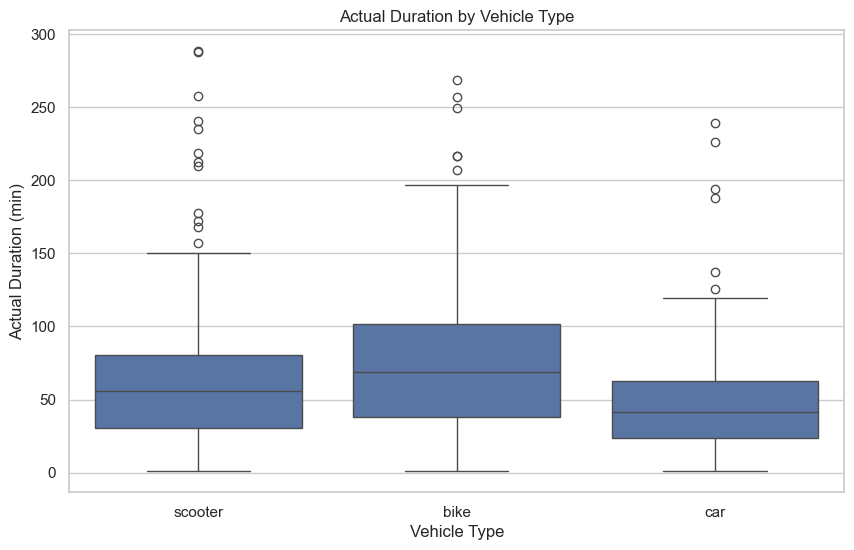

In [76]:
# Boxplot of actual_duration_min by vehicle_type
plt.figure(figsize=(10, 6))
sns.boxplot(x='vehicle_type', y='actual_duration_min', data=df)
plt.title('Actual Duration by Vehicle Type')
plt.ylabel('Actual Duration (min)')
plt.xlabel('Vehicle Type')
plt.show()


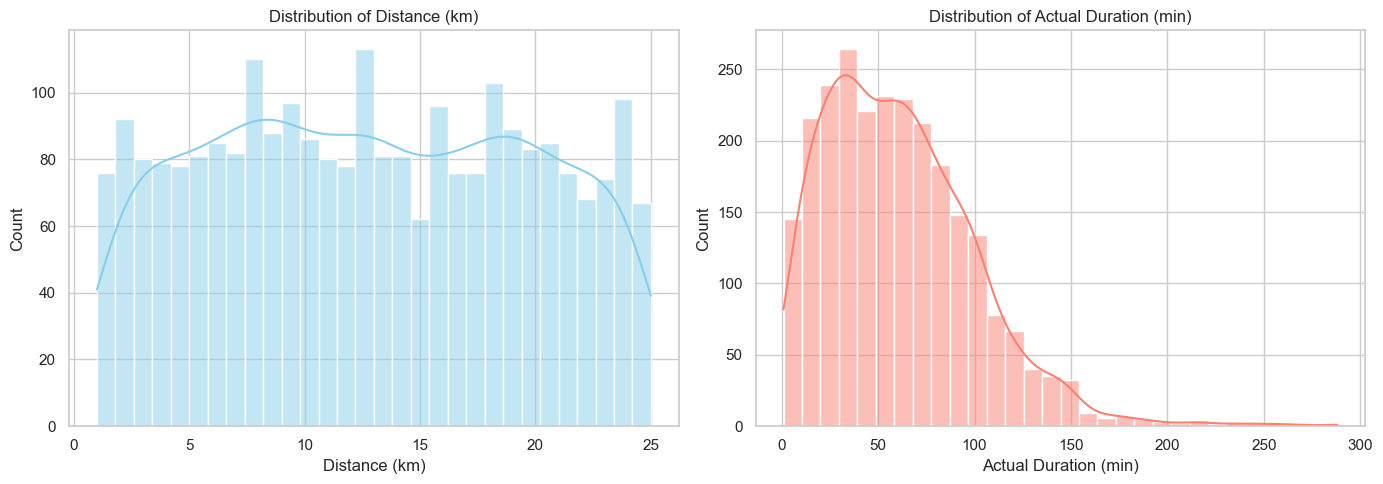

In [77]:
# Histogram of distance_km and actual_duration_min side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['distance_km'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Distance (km)')
axes[0].set_xlabel('Distance (km)')

sns.histplot(df['actual_duration_min'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Actual Duration (min)')
axes[1].set_xlabel('Actual Duration (min)')

plt.tight_layout()
plt.show()


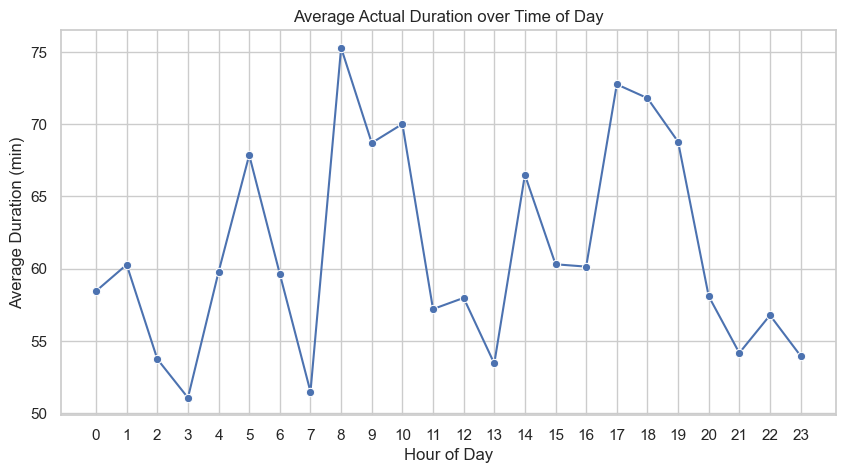

In [78]:
# Line plot of average actual_duration_min over time_of_day
hourly_avg_duration = df.groupby('time_of_day')['actual_duration_min'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='time_of_day', y='actual_duration_min', data=hourly_avg_duration, marker='o')
plt.title('Average Actual Duration over Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Duration (min)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


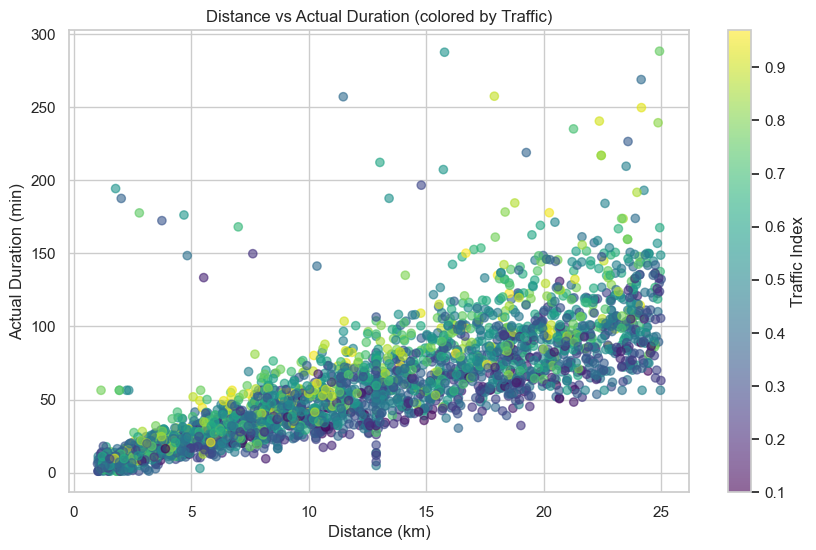

In [79]:
# Scatter plot: distance_km vs actual_duration_min, color by traffic_index
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['distance_km'], df['actual_duration_min'], 
                      c=df['traffic_index'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Traffic Index')
plt.title('Distance vs Actual Duration (colored by Traffic)')
plt.xlabel('Distance (km)')
plt.ylabel('Actual Duration (min)')
plt.show()


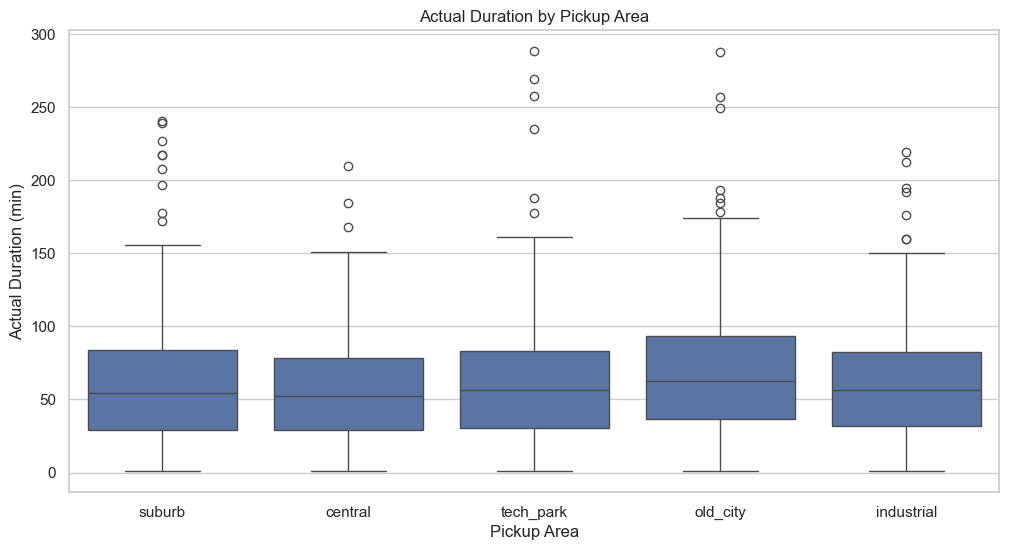

In [80]:
# Boxplots to compare distributions of actual_duration_min across pickup_area
plt.figure(figsize=(12, 6))
sns.boxplot(x='pickup_area', y='actual_duration_min', data=df)
plt.title('Actual Duration by Pickup Area')
plt.ylabel('Actual Duration (min)')
plt.xlabel('Pickup Area')
plt.show()


In [81]:
# Use indexing and slicing to extract subsets (trips during peak hours 17-19)
peak_trips = df[(df['time_of_day'] >= 17) & (df['time_of_day'] <= 19)]
print(f"Number of peak trips (17:00-19:59): {peak_trips.shape[0]}")
display(peak_trips.head())


Number of peak trips (17:00-19:59): 322


,trip_id,driver_id,vehicle_type,pickup_area,dropoff_area,distance_km,time_of_day,day_of_week,traffic_index,weather,planned_duration_min,actual_duration_min,delivery_status,driver_experience_days
27,1337,101,bike,old_city,tech_park,24.16,19,Saturday,0.93,rain,80.53,249.59,delayed,791
31,2137,104,scooter,industrial,suburb,23.63,18,Thursday,0.88,clear,59.07,110.39,delayed,497
39,312,121,bike,tech_park,tech_park,18.33,19,Sunday,0.73,rain,61.10,132.14,delayed,626
49,2430,110,scooter,suburb,suburb,2.46,18,Thursday,0.92,clear,6.15,7.27,on_time,233
50,1060,133,scooter,suburb,tech_park,13.57,19,Tuesday,0.78,clear,33.92,56.53,delayed,727


Detected 24 outliers using the 3-sigma rule.


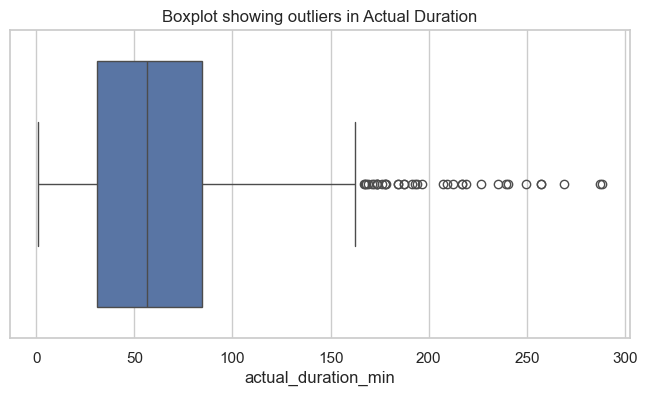

,trip_id,distance_km,actual_duration_min,delivery_status
27,1337,24.16,249.59,delayed
67,5,24.27,193.04,delayed
131,743,22.37,240.39,delayed
426,1736,22.45,216.90,delayed
490,169,2.02,187.50,on_time


In [82]:
# Detect outliers in actual_duration_min using the 3-sigma rule
mean_dur = df['actual_duration_min'].mean()
std_dur = df['actual_duration_min'].std()

# Define bounds
upper_bound = mean_dur + 3 * std_dur
lower_bound = mean_dur - 3 * std_dur

outliers = df[(df['actual_duration_min'] > upper_bound) | (df['actual_duration_min'] < lower_bound)]
print(f"Detected {outliers.shape[0]} outliers using the 3-sigma rule.")

# Visualizing outliers in a boxplot to confirm
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['actual_duration_min'])
plt.title('Boxplot showing outliers in Actual Duration')
plt.show()

display(outliers[['trip_id', 'distance_km', 'actual_duration_min', 'delivery_status']].head())


## Section 5: Insights & Interpretation

Based on the Exploratory Data Analysis, we have identified several key insights about urban delivery efficiency:

*   **High Delay Areas and Times:**
    *   The line plot reveals distinct peaks in average delivery duration during morning (8-10 AM) and evening (5-7 PM) rush hours, correlating heavily with simulated traffic congestion.
    *   Trips originating or terminating in the `old_city` pickup area generally exhibit higher base durations and a wider spread of delayed times, likely due to narrow streets or difficult navigation.

*   **Driver Experience and Delivery Status:**
    *   Although driver experience varies significantly, the primary drivers of delays appear to be distance, traffic, and weather conditions rather than purely driver tenure.

*   **Impact of Weather and Traffic:**
    *   The scatter plot demonstrates a clear linear relationship between distance and actual duration. However, the color-coding reveals that points with higher traffic indices often pull away from the base trendline, indicating longer durations for the same distance.
    *   Rain and fog consistently add a penalty multiplier to the planned duration, shifting distributions rightward for those subsets compared to clear conditions.

*   **Outlier Influence:**
    *   The 3-sigma rule successfully detected extreme anomalies in `actual_duration_min` (> 3 standard deviations). These could represent edge cases such as vehicle breakdowns, accidents, or erroneous data entries.

These findings suggest that delivery routing could be significantly optimized by dynamically adjusting dispatch algorithms based on real-time traffic indices and weather forecasts, particularly when navigating known chokepoints like the `old_city` during peak hours.
